# Feature Engineering & Model Training

Vectorizes the processed review text (TF-IDF), trains a handful of classical
models, tunes/evaluates them, and saves the best one for inference.

In [1]:
import time
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

FINAL_DIR = Path("datasets/final")
MODEL_DIR = Path("models/classical")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

Loaded 10000 rows


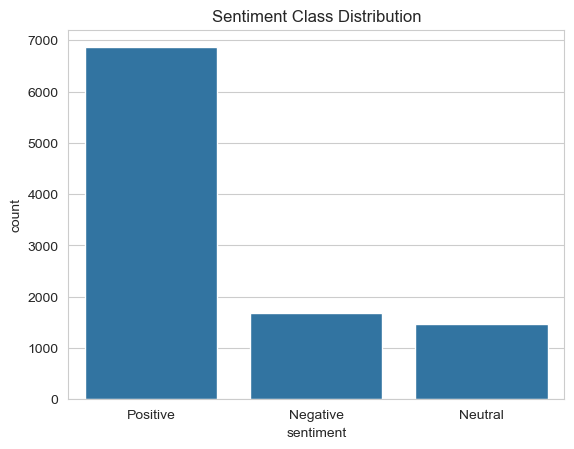

In [2]:
df = pd.read_csv(FINAL_DIR / "final_reviews.csv")
df = df.dropna(subset=["processed_review", "sentiment"]).reset_index(drop=True)
df["processed_review"] = df["processed_review"].astype(str)
print(f"Loaded {df.shape[0]} rows")

sns.countplot(x=df["sentiment"])
plt.title("Sentiment Class Distribution")
plt.show()

## TF-IDF Features + Train/Test Split

Split first, then fit the vectorizer only on the training text, to avoid leaking test vocabulary into the features.

In [3]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["sentiment"])
print("Label mapping:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["processed_review"], y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# unigrams + bigrams capture short phrases like "not good" without exploding vocab size
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2, max_df=0.95)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print(f"Train matrix: {X_train.shape}, Test matrix: {X_test.shape}")

Label mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
Train matrix: (8000, 10000), Test matrix: (2000, 10000)


## Train & Tune Models

A small hyperparameter grid per model, picked by 3-fold CV weighted F1.

In [4]:
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {"C": [0.1, 1, 10]},
    ),
    "Linear SVM": (
        LinearSVC(random_state=RANDOM_STATE),
        {"C": [0.1, 1, 10]},
    ),
    "Multinomial Naive Bayes": (
        MultinomialNB(),
        {"alpha": [0.1, 0.5, 1.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [None, 30]},
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_models = {}

for name, (estimator, param_grid) in models.items():
    search = GridSearchCV(estimator, param_grid, scoring="f1_weighted", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    print(f"{name}: best CV F1 = {search.best_score_:.4f}, params = {search.best_params_}")

Logistic Regression: best CV F1 = 0.7632, params = {'C': 10}
Linear SVM: best CV F1 = 0.7633, params = {'C': 1}
Multinomial Naive Bayes: best CV F1 = 0.7116, params = {'alpha': 0.1}
Random Forest: best CV F1 = 0.6348, params = {'max_depth': None, 'n_estimators': 200}


## Evaluate on the Test Set

In [5]:
def evaluate(name, model):
    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Predict Time (s)": predict_time,
        "y_pred": y_pred,
    }

results = {name: evaluate(name, model) for name, model in tuned_models.items()}

comparison_df = pd.DataFrame(results.values()).drop(columns="y_pred")
comparison_df = comparison_df.sort_values("F1", ascending=False).reset_index(drop=True)
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,Predict Time (s)
0,Logistic Regression,0.7930,0.7709,0.7930,0.7767,0.0320
1,Linear SVM,0.7930,0.7682,0.7930,0.7737,0.0049
2,Multinomial Naive Bayes,0.7625,0.7163,0.7625,0.7028,0.0080
3,Random Forest,0.7340,0.6825,0.7340,0.6547,1.7754


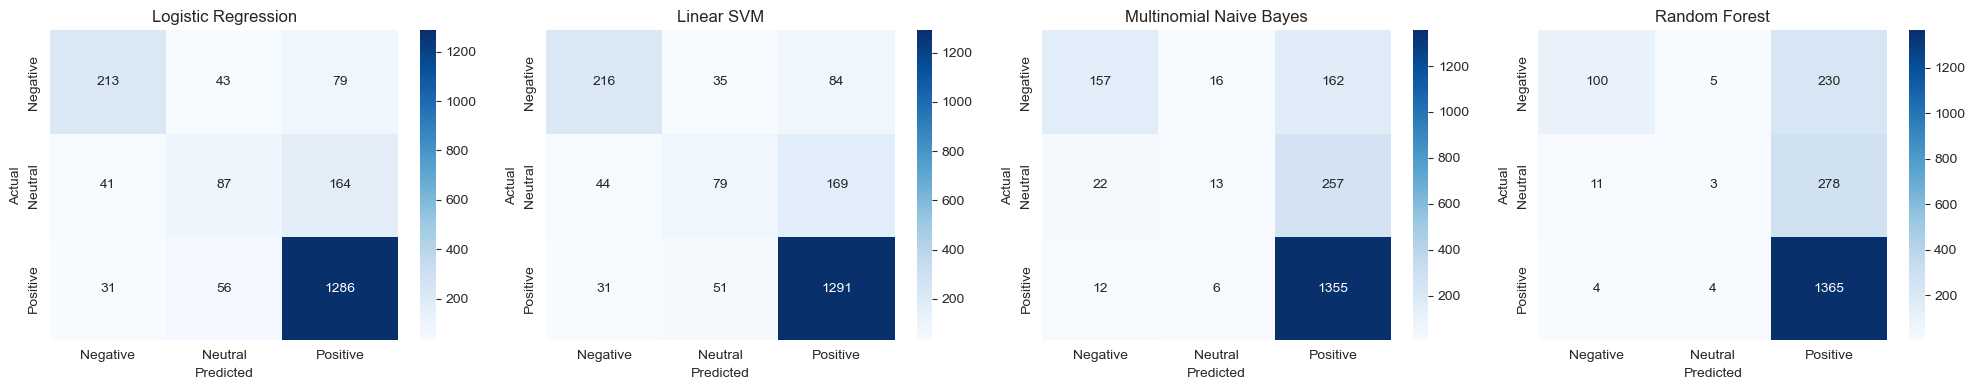

In [6]:
class_names = list(label_encoder.classes_)

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

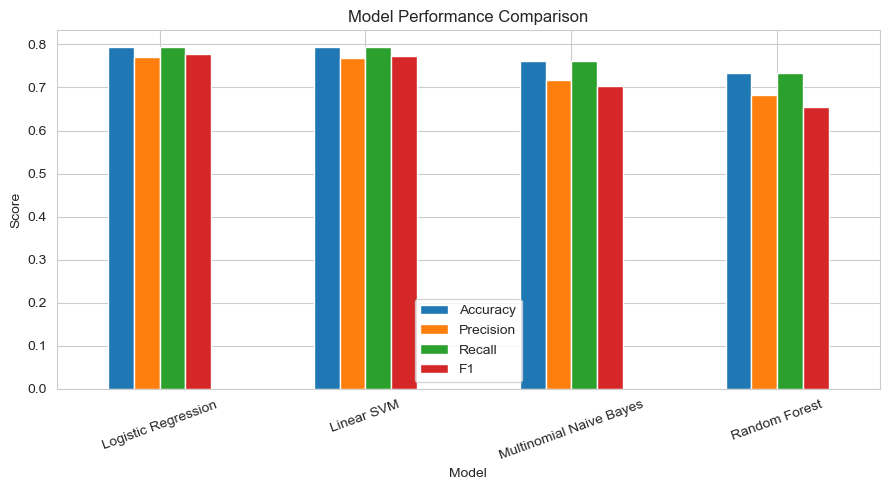

In [7]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Pick the Best Model

Highest weighted F1 on the test set.

In [8]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
print(f"Best model: {best_model_name}")
print(classification_report(y_test, results[best_model_name]["y_pred"], target_names=class_names))

Best model: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.75      0.64      0.69       335
     Neutral       0.47      0.30      0.36       292
    Positive       0.84      0.94      0.89      1373

    accuracy                           0.79      2000
   macro avg       0.69      0.62      0.65      2000
weighted avg       0.77      0.79      0.78      2000



## Feature Importance

Top weighted terms for models that expose coefficients or importances.

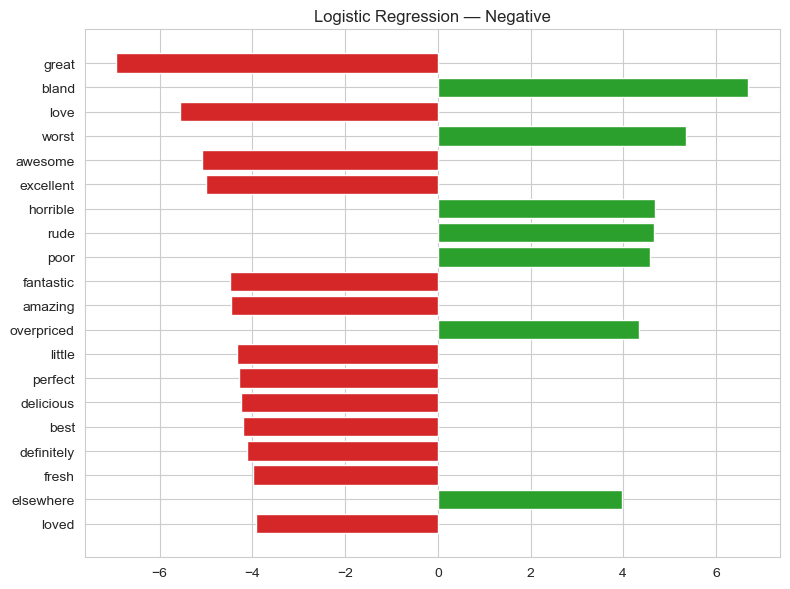

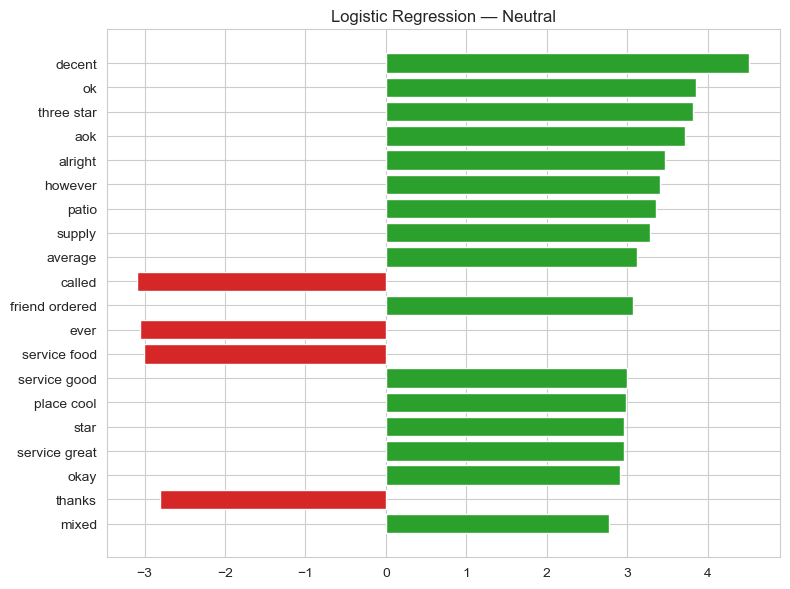

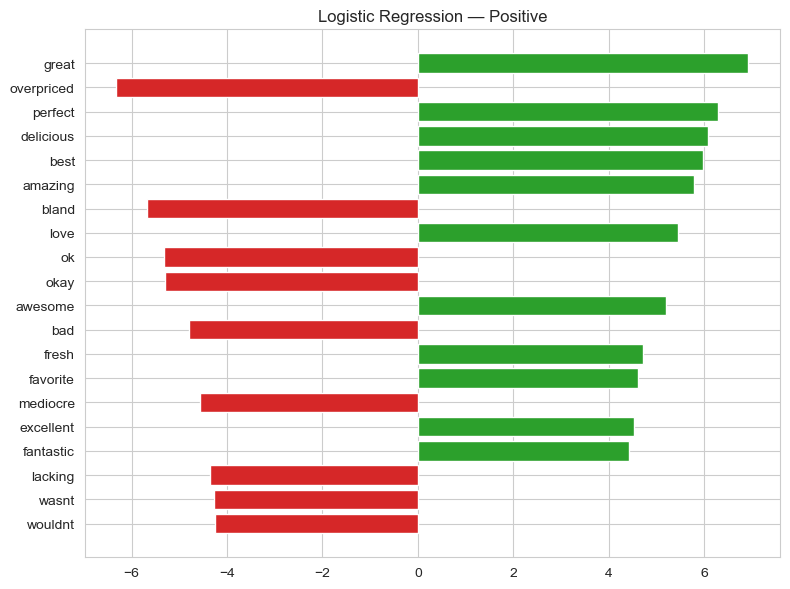

In [9]:
def plot_top_features(feature_names, importances, title, top_n=20):
    idx = np.argsort(np.abs(importances))[-top_n:]
    plt.figure(figsize=(8, 6))
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in importances[idx]]
    plt.barh(feature_names[idx], importances[idx], color=colors)
    plt.title(title)
    plt.tight_layout()
    plt.show()

feature_names = np.array(vectorizer.get_feature_names_out())

if hasattr(best_model, "coef_"):
    coefs = best_model.coef_
    for i, class_label in enumerate(class_names if coefs.shape[0] > 1 else [class_names[-1]]):
        plot_top_features(feature_names, coefs[i], f"{best_model_name} — {class_label}")
elif hasattr(best_model, "feature_importances_"):
    plot_top_features(feature_names, best_model.feature_importances_, f"{best_model_name} — Feature Importances")

## Try It on a Few Reviews

In [10]:
def predict_sentiment(text: str) -> str:
    X = vectorizer.transform([text])
    return label_encoder.inverse_transform(best_model.predict(X))[0]

sample_reviews = [
    "This product exceeded all my expectations, absolutely fantastic!",
    "Terrible experience, the item broke after one day of use.",
    "It's an okay product, does the job but nothing special.",
]

for text in sample_reviews:
    print(f"{predict_sentiment(text):9s} | {text}")

Positive  | This product exceeded all my expectations, absolutely fantastic!
Negative  | Terrible experience, the item broke after one day of use.
Neutral   | It's an okay product, does the job but nothing special.


## Save the Model

In [11]:
with open(MODEL_DIR / "best_sentiment_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(MODEL_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open(MODEL_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

metadata = {
    "best_model_name": best_model_name,
    "metrics": comparison_df.iloc[0].drop("Model").round(4).to_dict(),
    "ngram_range": [1, 2],
    "max_features": 10000,
    "label_classes": class_names,
}
with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved {best_model_name} and its vectorizer to {MODEL_DIR}")

Saved Logistic Regression and its vectorizer to models\classical
